---

MD004 - Algoritmos de Clustering (A: 8/01/2026) (B: 12/01/2026)

## Ejemplo clustering por densidades

**¿Qué es DBSCAN?** <br><br>

DBSCAN es un algoritmo de aprendizaje no supervisado que agrupa los datos basándose en la densidad de las muestras. A diferencia de los algoritmos de clustering basado en centroides,DBSCAN no asume que los clústeres sean circulares. Es muy resistente a outliers. <br>
No hace falta configurar un parámetro $k$, pero si que hace falta configurar los parámetros ``eps`` (esfera de influencia de los nodos) y ``MinPts`` (cantidad de muestras que debe tener un nodo en su área eps para que se considere core). <br><br>

**¿Cómo se mide la "cercanía"?**
- Métrica de Distancia: normalmente se utiliza la distancia Euclidiana.
<br><br>



<div align="center">
    <div align="center">
        <div style="display:flex; justify-content:center; gap:16px; flex-wrap:wrap;">
            <img src="https://anderfernandez.com/blog/dbscan-python/DBSCAN_sklearn_python_hu_b6f51e1a7daea0fc.png" alt="Resultados DBSCAN" style="width:256; height:auto;" />
        </div>
    </div>
</div>

<br><br>

---


In [1]:
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Ejemplo Blobs

Creamos los datos con ``make_blobs``.

In [2]:
centers = [[1, 1], [-1, -1], [1, -1]]
x, labels_true = make_blobs(n_samples = 1000, centers = centers, cluster_std = 0.25, random_state = 42)

x = StandardScaler().fit_transform(x)

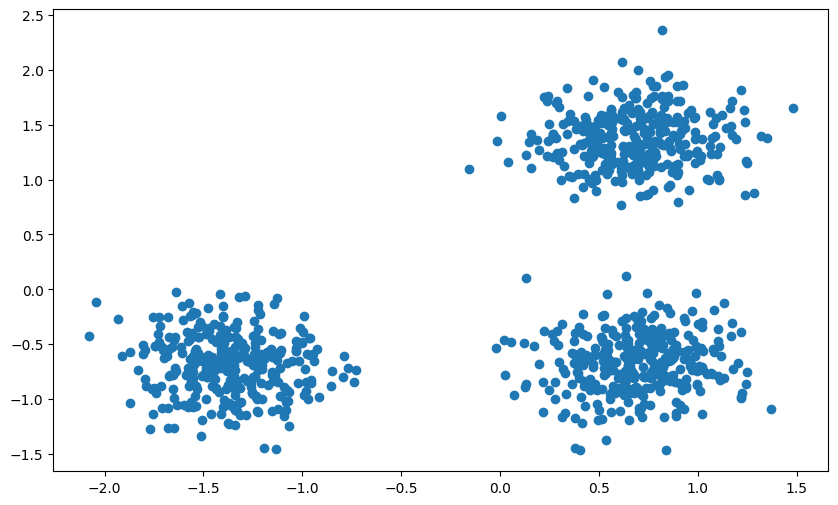

In [3]:
plt.figure(figsize = (10, 6))
plt.scatter(x[:, 0], x[:, 1])
plt.show()

Utilizamos KNN para buscar las distancias entre los nodos, luego lo representamos en un plot para aplicar el criterio del codo y así encontrar el valor de ``eps`` para la distancia deseada

In [4]:
neighbors = NearestNeighbors(n_neighbors = 4) # 2 * dimensiones (2) = 2 x 2 = 4
neighbors_fit = neighbors.fit(x)
distances, indices = neighbors_fit.kneighbors(x)

In [5]:
distances

array([[0.        , 0.02683407, 0.02758546, 0.04505138],
       [0.        , 0.022616  , 0.03683832, 0.06501313],
       [0.        , 0.00487806, 0.03344732, 0.03570197],
       ...,
       [0.        , 0.01210322, 0.01822992, 0.02268784],
       [0.        , 0.0614253 , 0.0766003 , 0.08341632],
       [0.        , 0.02667021, 0.0317307 , 0.04308702]], shape=(1000, 4))

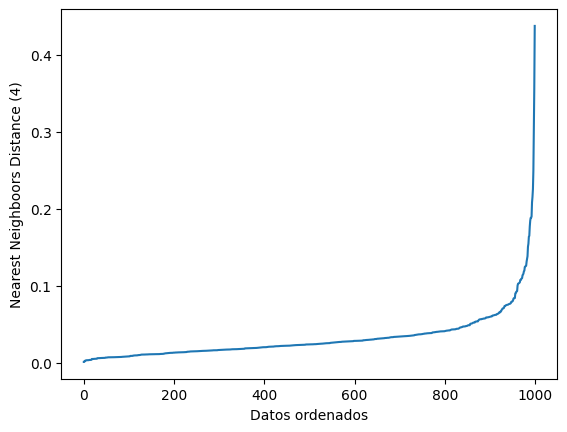

In [6]:
distances = np.sort(distances, axis = 0)
distances = distances[:,1]

plt.xlabel("Datos ordenados")
plt.ylabel("Nearest Neighboors Distance (4)")
plt.plot(distances)
plt.show()

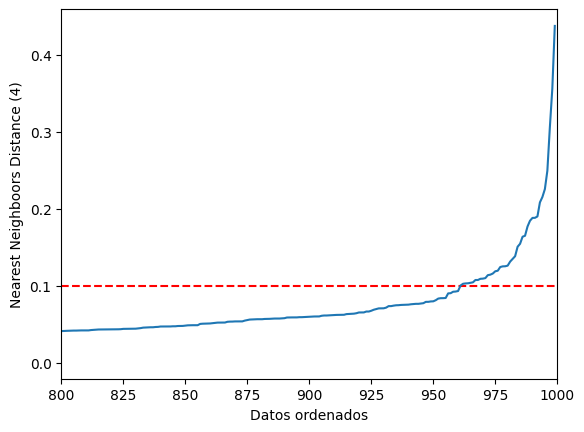

In [7]:
plt.xlabel("Datos ordenados")
plt.ylabel("Nearest Neighboors Distance (4)")
plt.xlim(800, 1000)
plt.hlines(0.10, 800, 1000, "r", linestyles="--")
plt.plot(distances)
plt.show()

Una vez encontrado el valor de ``eps`` ya se puede entrenar el modelo DBSCAN.

In [8]:
db = DBSCAN(eps=0.15, min_samples=4).fit(x)
labels = db.labels_

labels[:200]

array([ 0,  0,  1,  0,  1,  1,  0,  1,  2,  0,  1,  2,  2,  2,  2,  0,  2,
        2,  0,  1,  1,  1,  1,  0,  2,  1,  1,  0,  0,  2,  2,  0,  1,  0,
        1,  2,  1,  2,  0,  1,  0,  2,  0,  2,  1,  1,  2,  2,  2,  2,  1,
        1,  2,  2,  1,  0,  0,  2,  2,  2,  2,  0,  2,  1,  1,  1,  1,  1,
        2,  0,  2,  2,  0,  0,  1,  2,  1,  2,  0,  0,  2,  1,  1,  2,  2,
        0,  1,  2,  1,  2,  1,  0,  1,  2,  1,  2,  1,  1,  2,  1,  2,  1,
        2,  0,  0,  0,  0,  2,  1,  1,  0,  2,  0,  1, -1,  0,  2,  0, -1,
        1,  2,  1,  2,  2,  2,  1,  0,  2,  2,  1,  1,  0,  1,  0,  2,  2,
        1,  2,  0,  1,  0,  0,  1,  2,  2,  1,  0,  1,  0,  2,  1,  0,  2,
        1,  1,  1,  1,  1,  2,  0,  1,  1,  1,  2,  2,  0,  0,  1,  0,  1,
        2,  1,  2,  0,  1,  0,  2,  2,  2,  2,  2,  0,  0,  2,  1,  1,  2,
        1,  1,  2,  1,  0,  2,  0,  0,  2,  0,  2,  2,  2])

Como se puede ver se han encontrado 4 valores distintos. La implementación de DBSCAN de sklearn asigna el valor -1 a los nodos outliers y luego 0, 1, 2, etc. a los nodos en función del id de clúster al que pertenecen.

In [9]:
# Contamos la cantidad de clusters
n_clusters = len(set(labels))
print(f"La cantidad de posibles valores de labels es: {n_clusters}")

# Como se ha comentado en la cela anterior, el valor -1 indica los outliers, no es un clúster. Si hay outliers (es decir, que aparece el valor -1 en "labels"), 
# tenemos que restar 1 en la longitud de clases
n_clusters = n_clusters - (1 if -1 in labels else 0) # == si el valor -1 aparece en labels resta 1, si no resta 0

La cantidad de posibles valores de labels es: 4


In [10]:
# Contamos los outliers
n_noise = list(labels).count(-1) # .count(-1) cuenta la cantidad de -1 en la lista de "labels".

print(f"Cantidad de clusters: {n_clusters}")
print(f"Cantidad de outliers: {n_noise}")

Cantidad de clusters: 3
Cantidad de outliers: 25


In [11]:
datasetBlobs = pd.DataFrame({"X": x[:, 0], "Y": x[:, 1], "label": labels_true, "cluster": labels})

datasetBlobs

,X,Y,label,cluster
0,0.948212,-0.552630,2,0
1,1.113525,-0.824132,2,0
2,0.265490,1.411195,0,1
3,0.961689,-0.700384,2,0
4,0.486306,0.995547,0,1
...,...,...,...,...
995,-1.933100,-0.267080,1,-1
996,0.817943,1.440256,0,1
997,-1.402733,-0.420509,1,2
998,0.430448,-1.062758,2,0


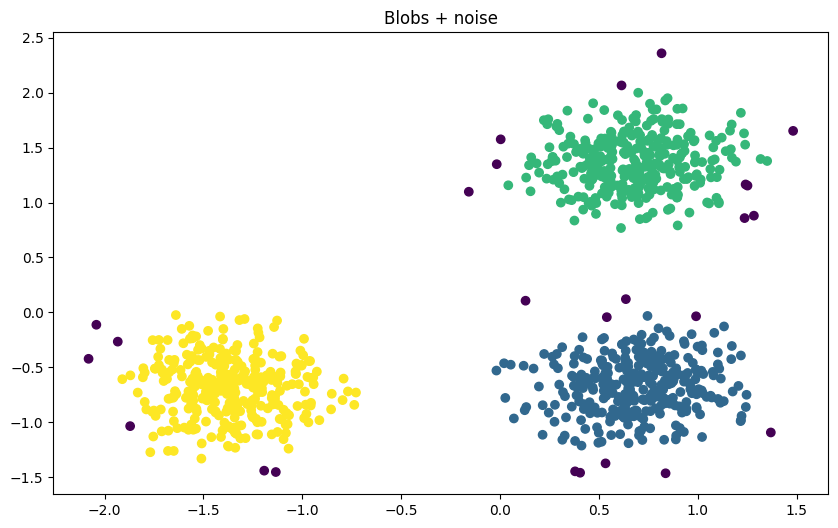

In [12]:
plt.figure(figsize = (10, 6))
plt.scatter(datasetBlobs.X, datasetBlobs.Y, c = datasetBlobs.cluster)
plt.title("Blobs + noise")
plt.show()

---

## Ejemplo Moons

In [13]:
features, true_labels = make_moons(n_samples = 500, noise = 0.1, random_state = 42)

x = features[:, 0]
y = features[:, 1]

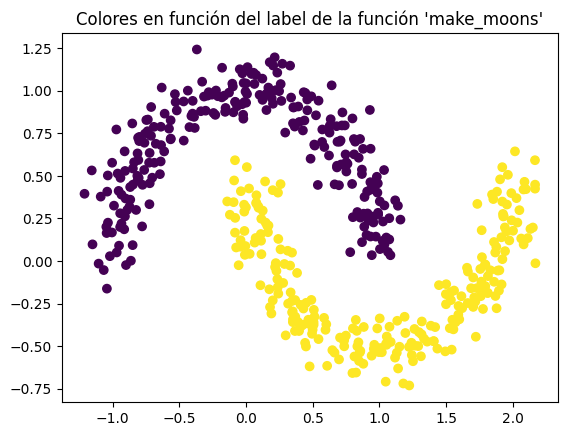

In [14]:
plt.title("Colores en función del label de la función \'make_moons\'")
plt.scatter(x, y, c=true_labels)
plt.show()

### Aplicad Kmeans

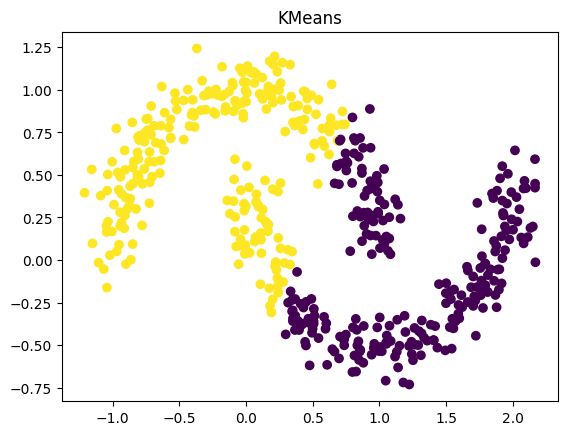

In [15]:
kmeans = KMeans(n_clusters = 2, random_state = 42).fit(features)
kmeansLabels = kmeans.labels_

plt.scatter(x, y, c = kmeansLabels)
plt.title("KMeans")
plt.show()

### Aplicad DBSCAN

In [16]:
neighbors = NearestNeighbors(n_neighbors = 4) # 2 * dimensiones (2) = 2 x 2 = 4
neighbors_fit = neighbors.fit(features)
distances, indices = neighbors_fit.kneighbors(features)

In [17]:
dist_4th = np.sort(distances[:, 3], axis=0)

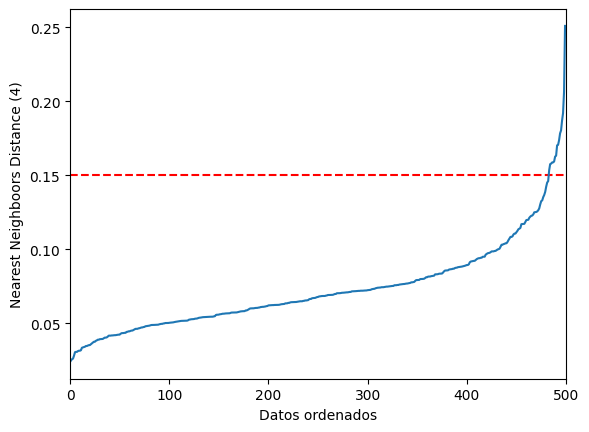

In [18]:
plt.xlabel("Datos ordenados")
plt.ylabel("Nearest Neighboors Distance (4)")
plt.xlim(0, 500)
plt.hlines(0.15, 0, 500, "r", linestyles="--")
plt.plot(dist_4th)
plt.show()

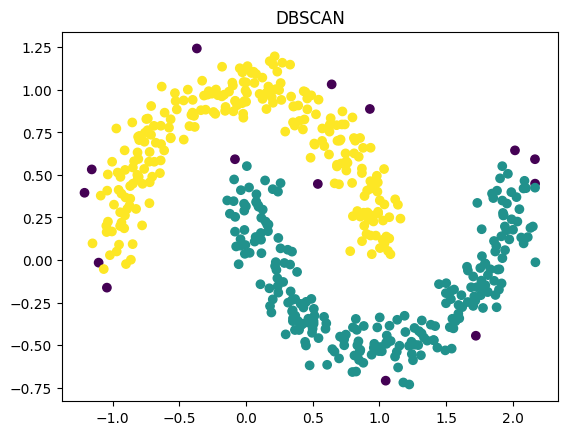

In [19]:
db = DBSCAN(eps=0.15, min_samples=10).fit(features)
dbLabels = db.labels_


plt.scatter(x, y, c = dbLabels)
plt.title("DBSCAN")
plt.show()

---